# ClinVar

In [1]:
import pandas as pd
from pathlib import Path

repo = "https://raw.githubusercontent.com/Joshua-Pillai/NephVar/main/USD"

genes = [
    "ADCY10", "AGXT", "APRT", "ATP6V0A4", "ATP6V1B1", "CA2", "CASR",
    "CLCN5", "CLCNKB", "CLDN16", "CLDN19", "CYP24A1", "FAM20A", "GRHPR",
    "HNF4A", "HOGA1", "HPRT1", "KCNJ1", "OCRL", "SLC12A1", "SLC22A12",
    "SLC2A9", "SLC34A1", "SLC34A3", "SLC3A1", "SLC4A1", "SLC7A9",
    "SLC9A3R1", "VDR", "XDH"
]

out = Path("/content/usd_csv")
out.mkdir(parents=True, exist_ok=True)

total = 0

for g in genes:
    df = pd.read_csv(f"{repo}/{g}.txt", sep="\t", low_memory=False)
    df.to_csv(out / f"{g}.csv", index=False)
    print(f"{g}: {len(df)} variants")
    total += len(df)

print(f"\nTotal: {total:,} variants across {len(genes)} genes")

df = pd.read_csv(out / "ADCY10.csv", low_memory=False)
print(f"ADCY10.csv: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.columns.tolist())

ADCY10: 687 variants
AGXT: 1114 variants
APRT: 284 variants
ATP6V0A4: 662 variants
ATP6V1B1: 845 variants
CA2: 254 variants
CASR: 2931 variants
CLCN5: 709 variants
CLCNKB: 717 variants
CLDN16: 414 variants
CLDN19: 220 variants
CYP24A1: 440 variants
FAM20A: 367 variants
GRHPR: 691 variants
HNF4A: 676 variants
HOGA1: 579 variants
HPRT1: 480 variants
KCNJ1: 421 variants
OCRL: 1047 variants
SLC12A1: 1080 variants
SLC22A12: 324 variants
SLC2A9: 525 variants
SLC34A1: 605 variants
SLC34A3: 921 variants
SLC3A1: 742 variants
SLC4A1: 938 variants
SLC7A9: 439 variants
SLC9A3R1: 215 variants
VDR: 542 variants
XDH: 1015 variants

Total: 20,884 variants across 30 genes
ADCY10.csv: 687 rows, 25 columns
['Name', 'Gene(s)', 'Protein change', 'Condition(s)', 'Accession', 'GRCh37Chromosome', 'GRCh37Location', 'GRCh38Chromosome', 'GRCh38Location', 'VariationID', 'AlleleID(s)', 'dbSNP ID', 'Canonical SPDI', 'Variant type', 'Molecular consequence', 'Germline classification', 'Germline date last evaluated', 

In [2]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/usd_csv")

genes = [
    "ADCY10", "AGXT", "APRT", "ATP6V0A4", "ATP6V1B1", "CA2", "CASR",
    "CLCN5", "CLCNKB", "CLDN16", "CLDN19", "CYP24A1", "FAM20A", "GRHPR",
    "HNF4A", "HOGA1", "HPRT1", "KCNJ1", "OCRL", "SLC12A1", "SLC22A12",
    "SLC2A9", "SLC34A1", "SLC34A3", "SLC3A1", "SLC4A1", "SLC7A9",
    "SLC9A3R1", "VDR", "XDH"
]

frames = [
    pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g)
    for g in genes
]

usd = pd.concat(frames, ignore_index=True)

# Counts
print(f"Total rows:     {len(usd):>7,}")
print(f"Unique IDs:     {usd['VariationID'].nunique():>7,}")
print(f"Duplicate rows: {len(usd) - usd['VariationID'].nunique():>7,}")

# Across-file duplicates
dup_vids = usd["VariationID"].value_counts().loc[lambda x: x > 1]
dup_rows = usd[usd["VariationID"].isin(dup_vids.index)]

overlap = (
    dup_rows
    .groupby("VariationID")["source"]
    .apply(lambda s: " + ".join(sorted(s.unique())))
)

print(f"\nVariants in >1 file: {len(dup_vids)}")
print("\nOverlap patterns:")
print(overlap.value_counts().to_string())

# Variant types among duplicates
unique_dups = dup_rows.drop_duplicates("VariationID")

print(f"\nVariant types ({len(unique_dups)} unique duplicated variants):")
print(unique_dups["Variant type"].value_counts().to_string())

# Non-CNV duplicates
cnv = {
    "copy number gain",
    "copy number loss",
    "Deletion",
    "Duplication"
}

non_cnv = unique_dups[~unique_dups["Variant type"].isin(cnv)]

if len(non_cnv) > 0:
    print(f"\nNon-CNV duplicates ({len(non_cnv)}):")
    print(
        non_cnv[
            ["VariationID", "Name", "Variant type", "Germline classification"]
        ].to_string(index=False)
    )

# Save report
dup_rows.sort_values(["VariationID", "source"]).to_csv(
    "/content/usd_duplicate_report.csv",
    index=False
)

Total rows:      20,884
Unique IDs:      20,587
Duplicate rows:     297

Variants in >1 file: 211

Overlap patterns:
source
HPRT1 + OCRL                      95
CLCN5 + HPRT1 + OCRL              73
GRHPR + SLC34A3                   15
FAM20A + SLC9A3R1                  4
CASR + CLDN16                      3
SLC3A1 + XDH                       3
CYP24A1 + HNF4A                    3
FAM20A + SLC4A1 + SLC9A3R1         3
KCNJ1 + SLC22A12                   3
AGXT + ATP6V1B1 + SLC3A1 + XDH     3
ATP6V1B1 + SLC3A1 + XDH            2
ADCY10 + CLCNKB + CLDN19           2
ATP6V1B1 + SLC3A1                  1
CLCNKB + CLDN19                    1

Variant types (211 unique duplicated variants):
Variant type
copy number gain    104
copy number loss    101
Duplication           3
Deletion              1
Indel                 1
Complex               1

Non-CNV duplicates (2):
 VariationID                                              Name Variant type Germline classification
      545551 NC_000023.10:g

In [3]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/usd_csv")

genes = [
    "ADCY10", "AGXT", "APRT", "ATP6V0A4", "ATP6V1B1", "CA2", "CASR",
    "CLCN5", "CLCNKB", "CLDN16", "CLDN19", "CYP24A1", "FAM20A", "GRHPR",
    "HNF4A", "HOGA1", "HPRT1", "KCNJ1", "OCRL", "SLC12A1", "SLC22A12",
    "SLC2A9", "SLC34A1", "SLC34A3", "SLC3A1", "SLC4A1", "SLC7A9",
    "SLC9A3R1", "VDR", "XDH"
]

# Load and concatenate all USD gene files
frames = [
    pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g)
    for g in genes
]

usd = pd.concat(frames, ignore_index=True)

# Identify VariationIDs appearing in >1 gene file
vid_counts = usd["VariationID"].value_counts()
dup_vids = vid_counts[vid_counts > 1].index

# Split into two datasets
single_gene = usd[~usd["VariationID"].isin(dup_vids)].reset_index(drop=True)

multi_gene = (
    usd[usd["VariationID"].isin(dup_vids)]
    .sort_values(["VariationID", "source"])
    .reset_index(drop=True)
)

# For the multi-gene file, collapse to one row per variant with the gene list
multi_gene_collapsed = (
    multi_gene
    .groupby("VariationID")
    .agg({
        "source": lambda s: " + ".join(sorted(s.unique())),
        "Name": "first",
        "Gene(s)": "first",
        "Variant type": "first",
        "Molecular consequence": "first",
        "Germline classification": "first",
        "Germline date last evaluated": "first",
        "Germline review status": "first",
    })
    .rename(columns={"source": "appears_in_gene_files"})
    .reset_index()
)

# Save
single_gene.to_csv("/content/usd_single_gene.csv", index=False)
multi_gene_collapsed.to_csv("/content/usd_multi_gene.csv", index=False)

# Report
print(f"Original total rows:        {len(usd):>7,}")
print(f"Single-gene variants:       {len(single_gene):>7,}  → usd_single_gene.csv")
print(f"Multi-gene variants:        {len(multi_gene_collapsed):>7,}  → usd_multi_gene.csv")

print(f"\nReconciliation:")
print(
    f"  {len(single_gene):,} + {len(multi_gene):,} "
    f"(raw multi-gene rows) = {len(single_gene) + len(multi_gene):,}"
)
print(
    f"  {len(single_gene):,} + {len(multi_gene_collapsed):,} "
    f"(unique multi-gene variants) = "
    f"{len(single_gene) + len(multi_gene_collapsed):,} unique variants total"
)

Original total rows:         20,884
Single-gene variants:        20,376  → usd_single_gene.csv
Multi-gene variants:            211  → usd_multi_gene.csv

Reconciliation:
  20,376 + 508 (raw multi-gene rows) = 20,884
  20,376 + 211 (unique multi-gene variants) = 20,587 unique variants total


# Variant types

In [4]:
import pandas as pd

df = pd.read_csv("/content/usd_single_gene.csv", low_memory=False)
print(f"Total variants: {len(df):,}\n")

# Variant type (DNA-level)
print("Variant type distribution:")
vt = df["Variant type"].value_counts(dropna=False)
vt_pct = (vt / len(df) * 100).round(2)
print(pd.DataFrame({"count": vt, "percent": vt_pct}).to_string())

# Molecular consequence (functional effect)
print("\nMolecular consequence (top 15):")
mc = df["Molecular consequence"].value_counts(dropna=False).head(15)
mc_pct = (mc / len(df) * 100).round(2)
print(pd.DataFrame({"count": mc, "percent": mc_pct}).to_string())

# Per-gene variant type breakdown
print("\nVariant type by gene:")
print(pd.crosstab(df["source"], df["Variant type"]).to_string())

Total variants: 20,376

Variant type distribution:
                           count  percent
Variant type                             
single nucleotide variant  17122    84.03
Deletion                    1192     5.85
copy number gain             542     2.66
copy number loss             511     2.51
Duplication                  492     2.41
Microsatellite               242     1.19
Indel                        144     0.71
Insertion                     83     0.41
Inversion                     26     0.13
Haplotype                      8     0.04
Complex                        7     0.03
Variation                      5     0.02
Translocation                  1     0.00
Phase unknown                  1     0.00

Molecular consequence (top 15):
                                                               count  percent
Molecular consequence                                                        
missense variant                                                7459    36.61
intron var

In [5]:
import pandas as pd
df = pd.read_csv("/content/usd_single_gene.csv", low_memory=False)
print("All unique classification labels:")
print(df["Germline classification"].value_counts(dropna=False).to_string())

All unique classification labels:
Germline classification
Uncertain significance                          8568
Likely benign                                   5760
Pathogenic                                      2431
Benign                                          1443
Likely pathogenic                               1362
Pathogenic/Likely pathogenic                     401
Benign/Likely benign                             388
Pathogenic; other                                 14
Uncertain significance/Uncertain risk allele       8
Likely pathogenic/Likely risk allele               1


In [6]:
df = pd.read_csv("/content/usd_single_gene.csv", low_memory=False)

missense = df[df["Molecular consequence"].str.contains("missense", case=False, na=False)]

print(f"Total missense variants: {len(missense):,}\n")

# Crosstab: rows = ClinVar label, columns = gene
ct = pd.crosstab(missense["Germline classification"], missense["source"], margins=True, margins_name="Total")
print(ct.to_string())

Total missense variants: 8,227

source                                        ADCY10  AGXT  APRT  ATP6V0A4  ATP6V1B1  CA2  CASR  CLCN5  CLCNKB  CLDN16  CLDN19  CYP24A1  FAM20A  GRHPR  HNF4A  HOGA1  HPRT1  KCNJ1  OCRL  SLC12A1  SLC22A12  SLC2A9  SLC34A1  SLC34A3  SLC3A1  SLC4A1  SLC7A9  SLC9A3R1  VDR  XDH  Total
Germline classification                                                                                                                                                                                                                                                                 
Benign                                             6     2     1         4         1    1     3      2      15       2       3        4       4      0      6      0      0      0     1        1         0      11        1        4       0       2       0         1    0    3     78
Benign/Likely benign                               4     8     1         5         2    1     4      3       5       2       

# Variant histories

In [7]:
import pandas as pd
import gzip
import urllib.request
from pathlib import Path

# Load the usd variant lists
single_gene = pd.read_csv("/content/usd_single_gene.csv", low_memory=False)
multi_gene = pd.read_csv("/content/usd_multi_gene.csv", low_memory=False)

# Use all unique usd VariationIDs as keys
target_ids = set(
    pd.concat([
        single_gene["VariationID"],
        multi_gene["VariationID"]
    ])
    .dropna()
    .astype(str)
)

print(f"Targeting {len(target_ids):,} usd VariationIDs")

# Download submission_summary.txt.gz from NCBI FTP
url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/submission_summary.txt.gz"
local = Path("/content/submission_summary.txt.gz")

if not local.exists():
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, local)
    print(f"  Saved: {local.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Using cached file: {local.stat().st_size / 1e6:.1f} MB")

# Stream-filter: read line-by-line, keep only rows matching CAKUT VariationIDs
matched_rows = []
header_line = None
n_total = 0

with gzip.open(local, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("##"):           # metadata header lines
            continue

        if line.startswith("#"):            # column header
            header_line = line.lstrip("#").strip().split("\t")
            continue

        n_total += 1
        cols = line.rstrip("\n").split("\t")

        # VariationID is the first column
        if cols[0] in target_ids:
            matched_rows.append(cols)

print(f"\nScanned {n_total:,} submission records")
print(f"Matched to usd variants: {len(matched_rows):,}")

# Build dataframe
history = pd.DataFrame(matched_rows, columns=header_line)

# Keep both string and numeric-friendly VariationID handling clean
history["VariationID"] = pd.to_numeric(history["VariationID"], errors="coerce").astype("Int64")

# Save
history.to_csv("/content/usd_submission_history.csv", index=False)

print(f"\nSaved: /content/usd_submission_history.csv")
print(
    f"  {len(history):,} submissions across "
    f"{history['VariationID'].nunique():,} variants"
)

# Sanity check: how many usd variants got at least one submission?
matched_variants = set(history["VariationID"].dropna().astype(str))
unmatched = target_ids - matched_variants

print(f"  Variants with submissions: {len(matched_variants):,} / {len(target_ids):,}")
print(f"  Variants with NO submissions: {len(unmatched):,}")

Targeting 20,587 usd VariationIDs
  Saved: 382.0 MB

Scanned 6,362,731 submission records
Matched to usd variants: 31,290

Saved: /content/usd_submission_history.csv
  31,290 submissions across 20,587 variants
  Variants with submissions: 20,587 / 20,587
  Variants with NO submissions: 0


Total submissions: 31,290
Unique variants: 20,587
Mean submissions per variant: 1.52 (95% CI: 1.50–1.54)
Median submissions per variant: 1
Max submissions for a single variant: 33

Distribution of submissions per variant:
1     15246
2      3251
3      1004
4       425
5       222
6       136
7        82
8        71
9        42
10       32
11       19
12       19
13       11
14        6
15        4

Variants with >10 submissions: 76 (0.4%)


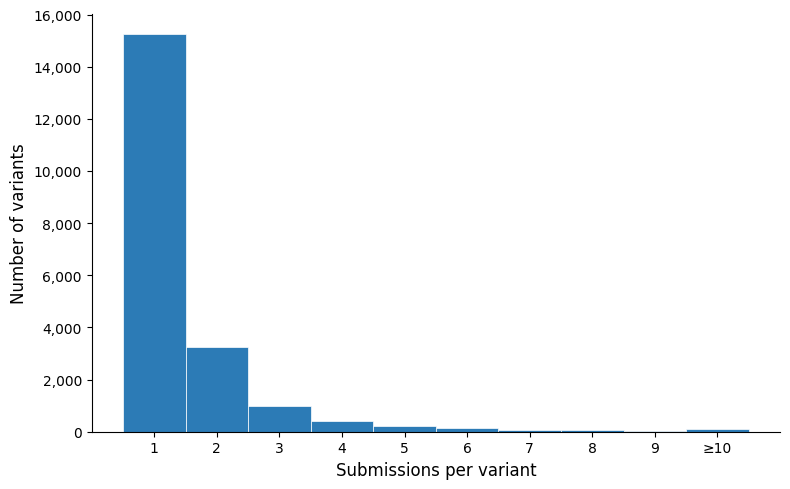

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# Load CAKUT submission history
history = pd.read_csv("/content/usd_submission_history.csv", low_memory=False)

# Submissions per variant
sub_counts = history.groupby("VariationID").size()

# Summary statistics
n = sub_counts.shape[0]
mean = sub_counts.mean()
median = sub_counts.median()
max_subs = sub_counts.max()

# Mean and 95% CI via t-distribution
se = stats.sem(sub_counts)
ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

print(f"Total submissions: {len(history):,}")
print(f"Unique variants: {n:,}")
print(f"Mean submissions per variant: {mean:.2f} (95% CI: {ci_low:.2f}–{ci_high:.2f})")
print(f"Median submissions per variant: {median:.0f}")
print(f"Max submissions for a single variant: {max_subs}")
print()

print("Distribution of submissions per variant:")
print(sub_counts.value_counts().sort_index().head(15).to_string())

over_10 = (sub_counts > 10).sum()
print(f"\nVariants with >10 submissions: {over_10:,} ({over_10 / n * 100:.1f}%)")

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 5))

cap = 10
capped = sub_counts.clip(upper=cap)
bins = np.arange(0.5, cap + 1.5, 1)

ax.hist(capped, bins=bins, color="#2c7bb6", edgecolor="white", linewidth=0.5)

ax.set_xlabel("Submissions per variant", fontsize=12)
ax.set_ylabel("Number of variants", fontsize=12)

ax.set_xticks(range(1, cap + 1))
ax.set_xticklabels([str(i) if i < cap else "≥10" for i in range(1, cap + 1)])

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/usd_submissions_per_variant.png", dpi=300)
plt.show()

In [11]:
import pandas as pd

history = pd.read_csv("/content/usd_submission_history.csv", low_memory=False)

history["DateLastEvaluated"] = pd.to_datetime(
    history["DateLastEvaluated"],
    errors="coerce"
)

history["year"] = history["DateLastEvaluated"].dt.year

def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

clean = history.dropna(subset=["VariationID", "DateLastEvaluated", "year", "bucket"]).copy()

# Sort chronologically
clean = clean.sort_values(["VariationID", "DateLastEvaluated"])

years = range(int(clean["year"].min()), int(clean["year"].max()) + 1)

rows = []

for y in years:
    # Keep all submissions up to that year
    up_to_year = clean[clean["year"] <= y]

    # For each variant, keep latest known classification as of that year
    latest = (
        up_to_year
        .sort_values(["VariationID", "DateLastEvaluated"])
        .drop_duplicates("VariationID", keep="last")
    )

    counts = latest["bucket"].value_counts()

    rows.append({
        "year": y,
        "P": counts.get("P", 0),
        "LP": counts.get("LP", 0),
        "VUS": counts.get("VUS", 0),
        "LB": counts.get("LB", 0),
        "B": counts.get("B", 0),
        "total_unique_variants": latest["VariationID"].nunique()
    })

current_by_year = pd.DataFrame(rows).set_index("year")

print("Latest classification as of each year, one category per variant:")
print(current_by_year.to_string())

current_by_year.to_csv("/content/usd_latest_classification_by_year.csv")
print("\nSaved: /content/usd_latest_classification_by_year.csv")

Latest classification as of each year, one category per variant:
         P    LP   VUS    LB     B  total_unique_variants
year                                                     
1972     1     0     0     0     0                      1
1973     1     0     0     0     0                      1
1974     1     0     0     0     0                      1
1975     1     0     0     0     0                      1
1976     1     0     0     0     0                      1
1977     1     0     0     0     0                      1
1978     1     0     0     0     0                      1
1979     1     0     0     0     0                      1
1980     1     0     0     0     0                      1
1981     1     0     0     0     0                      1
1982     2     0     0     0     0                      2
1983     5     0     0     0     0                      5
1984     6     0     0     0     0                      6
1985     6     0     0     0     0                      6
1986   

In [12]:
import numpy as np
from scipy import stats
import pandas as pd

# Use the reclassification-adjusted table:
# one latest classification per variant per year
try:
    trend_df = current_by_year.copy()
except NameError:
    trend_df = pd.read_csv(
        "/content/usd_latest_classification_by_year.csv",
        index_col="year"
    )

# Make sure year is a normal column
trend_df = trend_df.reset_index()

# Standardize year column name if needed
if "index" in trend_df.columns and "year" not in trend_df.columns:
    trend_df = trend_df.rename(columns={"index": "year"})

# Restrict to modern ClinVar era
trend_df = trend_df[trend_df["year"] >= 2013].copy()

x = trend_df["year"].values

print(f"Year range: {trend_df['year'].min()}–{trend_df['year'].max()}\n")

for bucket in ["P", "LP", "VUS", "LB", "B"]:
    if bucket not in trend_df.columns:
        continue

    y = trend_df[bucket].values

    if y.max() == 0:
        continue

    # Linear fit
    slope_lin, intercept_lin, r_lin, _, _ = stats.linregress(x, y)
    r2_lin = r_lin ** 2

    # Exponential fit requires positive values
    mask = y > 0

    if mask.sum() < 3:
        print(f"{bucket}: not enough positive yearly values for exponential fit")
        print()
        continue

    log_y = np.log(y[mask])
    slope_exp, intercept_exp, r_exp, _, _ = stats.linregress(x[mask], log_y)
    r2_exp = r_exp ** 2

    better = "exponential" if r2_exp > r2_lin else "linear"

    growth_pct = (np.exp(slope_exp) - 1) * 100

    if slope_exp > 0:
        doubling = f"{np.log(2) / slope_exp:.3f} yrs"
    else:
        doubling = "not applicable"

    print(f"{bucket} [{better}]:")
    print(
        f"  Linear:      y = {slope_lin:.2f}x + ({intercept_lin:.2f})   "
        f"R² = {r2_lin:.4f}   slope = {slope_lin:+.1f} variants/yr"
    )
    print(
        f"  Exponential: y = e^({slope_exp:.4f}x + ({intercept_exp:.4f}))   "
        f"R² = {r2_exp:.4f}   growth = {growth_pct:+.1f}%/yr   "
        f"doubling = {doubling}"
    )
    print()

Year range: 2013–2026

P [exponential]:
  Linear:      y = 150.01x + (-301292.10)   R² = 0.9568   slope = +150.0 variants/yr
  Exponential: y = e^(0.0942x + (-182.9838))   R² = 0.9749   growth = +9.9%/yr   doubling = 7.355 yrs

LP [exponential]:
  Linear:      y = 118.59x + (-238952.22)   R² = 0.8621   slope = +118.6 variants/yr
  Exponential: y = e^(0.3038x + (-607.8110))   R² = 0.9766   growth = +35.5%/yr   doubling = 2.282 yrs

VUS [exponential]:
  Linear:      y = 697.66x + (-1406036.40)   R² = 0.8712   slope = +697.7 variants/yr
  Exponential: y = e^(0.4268x + (-855.0066))   R² = 0.9436   growth = +53.2%/yr   doubling = 1.624 yrs

LB [exponential]:
  Linear:      y = 483.06x + (-973714.28)   R² = 0.8398   slope = +483.1 variants/yr
  Exponential: y = e^(0.5451x + (-1094.9088))   R² = 0.9558   growth = +72.5%/yr   doubling = 1.271 yrs

B [linear]:
  Linear:      y = 149.51x + (-301041.95)   R² = 0.8903   slope = +149.5 variants/yr
  Exponential: y = e^(0.3406x + (-681.6844))   R² =

# Reclassification rates

In [14]:
import pandas as pd

dataset = "usd"   # change to "cgn" if needed

history = pd.read_csv(f"/content/{dataset}_submission_history.csv", low_memory=False)
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")

def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    if "Pathogenic/Likely pathogenic" in s:
        return "P"
    if "Benign/Likely benign" in s:
        return "B"
    if "Uncertain" in s:
        return "VUS"
    if "Likely pathogenic" in s:
        return "LP"
    if "Likely benign" in s:
        return "LB"
    if "Pathogenic" in s:
        return "P"
    if "Benign" in s:
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

# Work only with submissions that have both a date and a clean bucket
dated = history.dropna(subset=["VariationID", "DateLastEvaluated", "bucket"]).copy()
dated = dated.sort_values(["VariationID", "DateLastEvaluated"])

# First-ever and most-recent submission per variant
first = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

# Combine first and latest classification
first_latest = (
    first[["VariationID", "DateLastEvaluated", "bucket"]]
    .rename(columns={
        "DateLastEvaluated": "first_date",
        "bucket": "first_bucket"
    })
    .merge(
        latest[["VariationID", "DateLastEvaluated", "bucket"]]
        .rename(columns={
            "DateLastEvaluated": "latest_date",
            "bucket": "latest_bucket"
        }),
        on="VariationID",
        how="inner"
    )
)

# Reclassification = first bucket differs from latest bucket
reclassified = first_latest[
    first_latest["first_bucket"] != first_latest["latest_bucket"]
].copy()

not_reclassified = first_latest[
    first_latest["first_bucket"] == first_latest["latest_bucket"]
].copy()

reclassified["transition"] = (
    reclassified["first_bucket"] + "_to_" + reclassified["latest_bucket"]
)

reclassified["years_to_reclassification"] = (
    reclassified["latest_date"] - reclassified["first_date"]
).dt.days / 365.25

# Report
print(f"Variants with ≥1 dated, clean-bucket submission: {len(first_latest):,}")
print(f"Reclassified first-to-latest:                    {len(reclassified):,}  ({len(reclassified) / len(first_latest) * 100:.1f}%)")
print(f"Not reclassified first-to-latest:                {len(not_reclassified):,}  ({len(not_reclassified) / len(first_latest) * 100:.1f}%)")

print("\nReclassification direction:")
print(reclassified["transition"].value_counts().to_string())

print("\nFirst bucket counts:")
print(first_latest["first_bucket"].value_counts().to_string())

print("\nLatest bucket counts:")
print(first_latest["latest_bucket"].value_counts().to_string())

# Transition matrix
transition_matrix = pd.crosstab(
    first_latest["first_bucket"],
    first_latest["latest_bucket"],
    rownames=["First bucket"],
    colnames=["Latest bucket"]
)

print("\nFirst-to-latest transition matrix:")
print(transition_matrix.to_string())

# Save outputs
reclassified.to_csv(f"/content/{dataset}_all_reclassified_first_to_latest.csv", index=False)
not_reclassified.to_csv(f"/content/{dataset}_not_reclassified_first_to_latest.csv", index=False)
transition_matrix.to_csv(f"/content/{dataset}_first_latest_transition_matrix.csv")

print(f"\nSaved:")
print(f"  /content/{dataset}_all_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_not_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_first_latest_transition_matrix.csv")

Variants with ≥1 dated, clean-bucket submission: 20,157
Reclassified first-to-latest:                    830  (4.1%)
Not reclassified first-to-latest:                19,327  (95.9%)

Reclassification direction:
transition
LB_to_B      193
P_to_LP      188
LP_to_P      170
B_to_LB       80
VUS_to_LB     40
VUS_to_B      36
VUS_to_LP     32
P_to_VUS      30
LB_to_VUS     28
LP_to_VUS     15
VUS_to_P       9
P_to_B         7
P_to_LB        1
B_to_VUS       1

First bucket counts:
first_bucket
VUS    8516
LB     5941
P      2711
B      1551
LP     1438

Latest bucket counts:
latest_bucket
VUS    8473
LB     5841
P      2664
B      1706
LP     1473

First-to-latest transition matrix:
Latest bucket     B    LB    LP     P   VUS
First bucket                               
B              1470    80     0     0     1
LB              193  5720     0     0    28
LP                0     0  1253   170    15
P                 7     1   188  2485    30
VUS              36    40    32     9  8399

Sav

In [15]:
import pandas as pd
import numpy as np
from scipy import stats

dataset = "usd"   # change to "cgn" if needed

# Load submission history
history = pd.read_csv(f"/content/{dataset}_submission_history.csv", low_memory=False)

# Parse dates
history["DateLastEvaluated"] = pd.to_datetime(
    history["DateLastEvaluated"],
    errors="coerce"
)

# Bucket ClinVar classifications into 5 groups
def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    if "Pathogenic/Likely pathogenic" in s:
        return "P"
    if "Benign/Likely benign" in s:
        return "B"
    if "Uncertain" in s:
        return "VUS"
    if "Likely pathogenic" in s:
        return "LP"
    if "Likely benign" in s:
        return "LB"
    if "Pathogenic" in s:
        return "P"
    if "Benign" in s:
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

# Keep only dated submissions with clean bucket labels
dated = history.dropna(
    subset=["VariationID", "DateLastEvaluated", "bucket"]
).copy()

dated = dated.sort_values(["VariationID", "DateLastEvaluated"])

# First and latest clean dated classification per variant
first = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

# Merge first and latest
first_latest = (
    first[["VariationID", "DateLastEvaluated", "bucket"]]
    .rename(columns={
        "DateLastEvaluated": "first_date",
        "bucket": "first_bucket"
    })
    .merge(
        latest[["VariationID", "DateLastEvaluated", "bucket"]]
        .rename(columns={
            "DateLastEvaluated": "latest_date",
            "bucket": "latest_bucket"
        }),
        on="VariationID",
        how="inner"
    )
)

# Reclassified variants only: first bucket differs from latest bucket
reclassified = first_latest[
    first_latest["first_bucket"] != first_latest["latest_bucket"]
].copy()

# Time to reclassification
reclassified["years_to_reclassification"] = (
    reclassified["latest_date"] - reclassified["first_date"]
).dt.days / 365.25

# Drop invalid/paradoxical intervals
reclassified = reclassified[
    reclassified["years_to_reclassification"] >= 0
].copy()

# Add transition label
reclassified["transition"] = (
    reclassified["first_bucket"] + "_to_" + reclassified["latest_bucket"]
)

# Mean and 95% CI function
def summarize_time(series):
    series = series.dropna()
    n = len(series)

    if n == 0:
        return pd.Series({
            "n": 0,
            "mean_years": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        })

    mean = series.mean()

    if n > 1:
        se = stats.sem(series)
        ci_low, ci_high = stats.t.interval(
            0.95,
            df=n - 1,
            loc=mean,
            scale=se
        )
    else:
        ci_low, ci_high = np.nan, np.nan

    return pd.Series({
        "n": n,
        "mean_years": mean,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

# Five key numbers: time to reclassification by starting category
summary = (
    reclassified
    .groupby("first_bucket")["years_to_reclassification"]
    .apply(summarize_time)
    .unstack()
    .reindex(["B", "LB", "VUS", "LP", "P"])
)

print(f"Total reclassified variants: {len(reclassified):,}")
print("\nMean time to reclassification by starting category:")
print(summary.round(2).to_string())

# Save simple outputs
reclassified.to_csv(
    f"/content/{dataset}_all_reclassified_first_to_latest.csv",
    index=False
)

summary.to_csv(
    f"/content/{dataset}_time_to_reclassification_by_starting_category.csv"
)

print(f"\nSaved:")
print(f"  /content/{dataset}_all_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_time_to_reclassification_by_starting_category.csv")

Total reclassified variants: 830

Mean time to reclassification by starting category:
                  n  mean_years  ci_low  ci_high
first_bucket                                    
B              81.0        4.28    3.52     5.04
LB            221.0        5.38    4.99     5.77
VUS           117.0        6.26    5.67     6.85
LP            185.0        4.27    3.74     4.79
P             226.0       10.20    8.81    11.60

Saved:
  /content/usd_all_reclassified_first_to_latest.csv
  /content/usd_time_to_reclassification_by_starting_category.csv


# NephVar Implementation

In [16]:
import pandas as pd, json, os, shutil, glob, re
from pathlib import Path

# 1) ensure usd (single-gene master) + history
try: usd
except NameError:
    usd = pd.read_csv("/content/usd_single_gene.csv", low_memory=False)
if "source" not in usd.columns and "appears_in_gene_files" in usd.columns:
    usd = usd.rename(columns={"appears_in_gene_files": "source"})
try: history
except NameError:
    history = pd.read_csv("/content/usd_submission_history.csv", low_memory=False)

# 2) master database
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], format="mixed", errors="coerce")
def bk(s):
    if pd.isna(s): return None
    return {"Pathogenic":"P","Likely pathogenic":"LP","Uncertain significance":"VUS","Benign":"B","Likely benign":"LB"}.get(str(s).strip())
history["bucket"] = history["ClinicalSignificance"].apply(bk)
dd = history.dropna(subset=["DateLastEvaluated","bucket"]).sort_values("DateLastEvaluated")
first  = dd.drop_duplicates("VariationID",keep="first")[["VariationID","bucket","DateLastEvaluated"]].rename(columns={"bucket":"first_class","DateLastEvaluated":"first_date"})
latest = dd.drop_duplicates("VariationID",keep="last")[["VariationID","bucket","DateLastEvaluated"]].rename(columns={"bucket":"latest_class","DateLastEvaluated":"latest_date"})
agg = history.groupby("VariationID").agg(n_submissions=("Submitter","size"), n_submitters=("Submitter","nunique"))
sev = {"P":4,"LP":3,"VUS":2,"LB":1,"B":0}
db = (usd[["VariationID","source","Name","Protein change","Variant type","Molecular consequence","Germline classification","Germline review status"]].drop_duplicates("VariationID")
      .rename(columns={"source":"gene","Protein change":"protein_change","Variant type":"variant_type","Molecular consequence":"consequence","Germline classification":"current_class","Germline review status":"review_status"}))
db = db.merge(first,on="VariationID",how="left").merge(latest,on="VariationID",how="left").merge(agg,on="VariationID",how="left")
db["reclassified"] = db["first_class"].notna() & (db["first_class"]!=db["latest_class"])
db["direction"] = db.apply(lambda r:"" if not r["reclassified"] else ("toward_pathogenic" if sev.get(r["latest_class"],-1)>sev.get(r["first_class"],-1) else "toward_benign"), axis=1)
db["first_year"] = db["first_date"].dt.year; db["latest_year"] = db["latest_date"].dt.year
for c in ["n_submissions","n_submitters"]: db[c]=db[c].fillna(0).astype(int)
db["first_date"]=db["first_date"].dt.strftime("%Y-%m-%d"); db["latest_date"]=db["latest_date"].dt.strftime("%Y-%m-%d")
db.to_csv("/content/usd_variant_database.csv", index=False)
db[db["reclassified"]].sort_values(["first_class","latest_class"]).to_csv("/content/usd_db_reclassified_all.csv", index=False)
db.sort_values("n_submitters", ascending=False).to_csv("/content/usd_db_by_submitters.csv", index=False)
db[db["current_class"].astype(str).str.contains("Conflicting", na=False)].to_csv("/content/usd_db_conflicting.csv", index=False)

# 3) ACMG bucket per variant + per-gene counts for landing cards
def acmg_bucket(s):
    if pd.isna(s):
        return "Other"
    tokens = [t.strip().lower() for t in re.split(r'[/;,]', str(s))]
    if "pathogenic" in tokens:        return "P"
    if "benign" in tokens:            return "B"
    if "likely pathogenic" in tokens: return "LP"
    if "likely benign" in tokens:     return "LB"
    if "uncertain significance" in tokens: return "VUS"
    return "Other"

db["acmg_bucket"] = db["current_class"].apply(acmg_bucket)

genes_list = sorted([x for x in db["gene"].unique() if x])

ACMG_ORDER = ["P","LP","VUS","LB","B","Other"]
ACMG_LABELS = {"P":"Pathogenic","LP":"Likely pathogenic","VUS":"Uncertain significance",
               "LB":"Likely benign","B":"Benign","Other":"Other / conflicting"}

panel_counts = {}
for gene in genes_list:
    sub = db[db["gene"]==gene]
    counts = sub["acmg_bucket"].value_counts().to_dict()
    panel_counts[gene] = {b: int(counts.get(b,0)) for b in ACMG_ORDER}
    panel_counts[gene]["total"] = len(sub)

print(f"Total variants: {len(db):,}")
for gene in genes_list:
    pc = panel_counts[gene]
    print(f"  {gene:<8} total={pc['total']:>5}  "
          + "  ".join(f"{b}={pc[b]}" for b in ACMG_ORDER))

# 4) timelines (per-variant submission history)
h = history.copy()
h["date"] = h["DateLastEvaluated"].dt.strftime("%Y-%m-%d").fillna("—")
h = h.sort_values("DateLastEvaluated", na_position="last")
timelines = {int(v):[{"date":r["date"],"sub":str(r["Submitter"]),"sig":str(r["ClinicalSignificance"]),
                       "b":(r["bucket"] if pd.notna(r["bucket"]) else "")} for _,r in g.iterrows()]
             for v,g in h.groupby("VariationID")}

Total variants: 20,587
  ADCY10   total=  687  P=41  LP=13  VUS=329  LB=163  B=141  Other=0
  AGXT     total= 1114  P=338  LP=118  VUS=208  LB=387  B=63  Other=0
  APRT     total=  284  P=120  LP=31  VUS=87  LB=30  B=16  Other=0
  ATP6V0A4 total=  662  P=88  LP=42  VUS=274  LB=133  B=125  Other=0
  ATP6V1B1 total=  842  P=83  LP=51  VUS=271  LB=386  B=51  Other=0
  CA2      total=  254  P=44  LP=10  VUS=107  LB=66  B=27  Other=0
  CASR     total= 2931  P=247  LP=97  VUS=1585  LB=961  B=41  Other=0
  CLCN5    total=  709  P=244  LP=63  VUS=266  LB=88  B=48  Other=0
  CLCNKB   total=  715  P=78  LP=38  VUS=245  LB=182  B=172  Other=0
  CLDN16   total=  411  P=69  LP=26  VUS=190  LB=77  B=49  Other=0
  CLDN19   total=  217  P=20  LP=17  VUS=114  LB=50  B=16  Other=0
  CYP24A1  total=  440  P=49  LP=25  VUS=213  LB=80  B=73  Other=0
  FAM20A   total=  367  P=41  LP=20  VUS=174  LB=83  B=49  Other=0
  GRHPR    total=  691  P=157  LP=91  VUS=140  LB=268  B=35  Other=0
  HNF4A    total=  673 

In [17]:
from pathlib import Path

out_dir = Path("/content/html/USD/variants")
out_dir.mkdir(parents=True, exist_ok=True)

ACMG_COLORS = {"P":"var(--P)","LP":"var(--LP)","VUS":"var(--VUS)","LB":"var(--LB)","B":"var(--B)","Other":"var(--faint)"}

cards = ""
for gene in genes_list:
    pc = panel_counts[gene]
    boxes = "".join(
        f'<div class="acmgbox" style="background:{ACMG_COLORS[b]}">'
        f'<span class="acmgcount">{pc[b]}</span><span class="acmglabel">{b}</span></div>'
        for b in ACMG_ORDER
    )
    cards += f"""
    <a class="card" href="{gene}.html">
      <div class="card-head">
        <span class="gname">{gene}</span>
        <span class="gtotal">{pc['total']:,} variants</span>
      </div>
      <div class="acmgrow">{boxes}</div>
      <div class="cta">View variants &rarr;</div>
    </a>"""

html = f"""<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>USD Variants — NephVar</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;max-width:680px;line-height:1.6;margin-bottom:40px}}
.grid{{display:grid;grid-template-columns:repeat(auto-fill,minmax(280px,1fr));gap:16px}}
.card{{display:block;text-decoration:none;color:inherit;background:#fff;border:1px solid var(--line);
border-radius:6px;padding:22px;transition:transform .14s ease,box-shadow .14s ease,border-color .14s ease}}
.card:hover{{transform:translateY(-2px);box-shadow:0 12px 28px rgba(20,30,45,.10);border-color:#cdd9e4}}
.card-head{{display:flex;align-items:baseline;justify-content:space-between;margin-bottom:14px}}
.gname{{font-family:var(--serif);font-size:28px}}
.gtotal{{font-family:var(--mono);font-size:11px;color:var(--faint)}}
.acmgrow{{display:flex;gap:5px;margin-bottom:14px}}
.acmgbox{{flex:1;border-radius:4px;color:#fff;padding:6px 4px;text-align:center}}
.acmgcount{{display:block;font-family:var(--mono);font-size:14px;font-weight:400}}
.acmglabel{{display:block;font-family:var(--mono);font-size:9px;letter-spacing:.06em;opacity:.9}}
.cta{{font-family:var(--mono);font-size:12px;color:var(--accent)}}
.legend{{display:flex;flex-wrap:wrap;gap:14px;margin-top:32px;font-family:var(--mono);font-size:10.5px;color:var(--soft)}}
.legend span{{display:inline-flex;align-items:center;gap:6px}}
.dot{{width:9px;height:9px;border-radius:99px;display:inline-block}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../">NephVar</a> / <a href="../">USD</a> / Variants</div>
<h1>USD <em>Variants</em></h1>
<div class="sub">ClinVar-derived variant database for the 30 urinary stone disease
genes &mdash; {len(db):,} unique variants total. Select a gene to
browse its full variant list with classification history and submission timelines.</div>
<div class="grid">{cards}</div>
<div class="legend">
  <span><span class="dot" style="background:var(--P)"></span>Pathogenic (P)</span>
  <span><span class="dot" style="background:var(--LP)"></span>Likely pathogenic (LP)</span>
  <span><span class="dot" style="background:var(--VUS)"></span>Uncertain significance (VUS)</span>
  <span><span class="dot" style="background:var(--LB)"></span>Likely benign (LB)</span>
  <span><span class="dot" style="background:var(--B)"></span>Benign (B)</span>
  <span><span class="dot" style="background:var(--faint)"></span>Other / conflicting</span>
</div>
</div></body></html>"""

(out_dir / "index.html").write_text(html, encoding="utf-8")
print("Written: USD/variants/index.html")

Written: USD/variants/index.html


In [18]:
gene_template = """<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>{gene} Variants — NephVar USD</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;margin-bottom:24px;line-height:1.6}}
.controls{{display:flex;flex-wrap:wrap;gap:10px;align-items:center;margin-bottom:14px}}
input[type=text],select{{font-family:var(--sans);font-size:13px;padding:9px 12px;border:1px solid var(--line);
border-radius:4px;background:#fff;color:var(--ink)}}
input[type=text]{{flex:1;min-width:220px}}
.chk{{display:flex;align-items:center;gap:6px;font-family:var(--mono);font-size:12px;color:var(--soft);cursor:pointer}}
.count{{font-family:var(--mono);font-size:11px;color:var(--faint);margin-left:auto}}
table{{width:100%;border-collapse:collapse;font-size:13px;background:#fff;border:1px solid var(--line);border-radius:4px;overflow:hidden}}
th{{font-family:var(--mono);text-align:left;padding:11px 12px;background:#f6f5f1;font-weight:400;font-size:10.5px;
letter-spacing:.1em;text-transform:uppercase;color:var(--soft);cursor:pointer;white-space:nowrap}}
th:hover{{color:var(--ink)}}
td{{padding:9px 12px;border-top:1px solid var(--line)}}
tbody tr{{cursor:pointer}}tbody tr:hover td{{background:#f7f9fb}}
.mono{{font-family:var(--mono);font-size:11.5px}}
.pill{{font-family:var(--mono);display:inline-block;padding:2px 8px;border-radius:99px;font-size:10px;color:#fff}}
.arrow{{color:var(--faint);margin:0 4px}}
.flag{{font-family:var(--mono);font-size:10px;padding:1px 7px;border-radius:4px;background:#f0f3f6;color:var(--soft)}}
.flag.recl{{background:#fff3e0;color:#b25e00}}
.empty{{padding:40px;text-align:center;color:var(--faint)}}
.ovl{{position:fixed;inset:0;background:rgba(20,30,45,.45);display:none;align-items:flex-start;
justify-content:center;padding:40px 16px;overflow:auto;z-index:10}}
.modal{{background:#fff;border-radius:6px;max-width:680px;width:100%;padding:24px;box-shadow:0 20px 60px rgba(20,30,45,.3)}}
.modal h2{{font-family:var(--serif);margin:0 0 2px;font-size:24px}}
.modal .vid{{font-family:var(--mono);font-size:12px;color:var(--soft);margin-bottom:16px}}
.modal .vid a{{color:var(--accent);text-decoration:none}}.modal .vid a:hover{{text-decoration:underline}}
.grid{{display:grid;grid-template-columns:1fr 1fr;gap:8px 20px;font-size:13px;margin-bottom:18px}}
.grid div span{{color:var(--faint);display:block;font-family:var(--mono);font-size:10px;text-transform:uppercase;letter-spacing:.06em}}
.tl{{border-top:1px solid var(--line);padding-top:12px}}
.tl h3{{font-family:var(--mono);font-size:11px;text-transform:uppercase;letter-spacing:.08em;color:var(--soft);margin:0 0 8px}}
.tlrow{{display:grid;grid-template-columns:90px auto 1fr;gap:10px;align-items:center;padding:6px 0;
border-bottom:1px solid #f0f3f6;font-size:12.5px}}
.tlrow .d{{color:var(--faint);font-family:var(--mono)}}.tlrow .s{{color:var(--soft)}}
.x{{float:right;cursor:pointer;color:var(--faint);font-size:20px;line-height:1}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../../">NephVar</a> / <a href="../../">USD</a> / <a href="../">Variants</a> / {gene}</div>
<h1>{gene} <em>Variants</em></h1>
<div class="sub">{n_total:,} unique ClinVar variants &middot; click any row for full classification
history and submission timeline.</div>

<div class="controls">
  <input id="q" type="text" placeholder="Search variant, protein change, or Variation ID…">
  <select id="cls"><option value="">All current classes</option>
    <option>Pathogenic</option><option>Likely pathogenic</option><option>Uncertain significance</option>
    <option>Likely benign</option><option>Benign</option><option>Conflicting</option>
  </select>
  <label class="chk"><input type="checkbox" id="recl"> Reclassified only</label>
  <span class="count" id="count"></span>
</div>
<table><thead><tr>
  <th data-k="VariationID">Var ID</th>
  <th data-k="protein_change">Protein change</th>
  <th data-k="first_class">First &rarr; Latest</th>
  <th data-k="current_class">Current</th>
  <th data-k="n_submitters">Submitters</th>
  <th data-k="n_submissions">Subs</th>
  <th data-k="first_year">First yr</th>
</tr></thead><tbody id="rows"></tbody></table>
<div id="empty" class="empty" style="display:none">No variants match your search.</div>
</div>
<div class="ovl" id="ovl"><div class="modal" id="modal"></div></div>
<script>
const DATA={data_json}, TL={tl_json};
const C={{P:'var(--P)',LP:'var(--LP)',VUS:'var(--VUS)',LB:'var(--LB)',B:'var(--B)'}};
const BK={{Pathogenic:'P','Likely pathogenic':'LP','Uncertain significance':'VUS','Likely benign':'LB',Benign:'B'}};
const pill=c=>c?`<span class="pill" style="background:${{C[c]||'#9aa6b2'}}">${{c}}</span>`:'';
let sortK='n_submitters',sortDir=-1;
function g(i){{return document.getElementById(i)}}
const q=g('q'),cls=g('cls'),recl=g('recl');
function isR(d){{return d.reclassified===true||d.reclassified==='True'}}
function render(){{
  let r=DATA.filter(d=>{{
    const t=(q.value||'').toLowerCase();
    const hit=!t||[d.Name,d.protein_change,d.VariationID].join(' ').toLowerCase().includes(t);
    return hit&&(!cls.value||String(d.current_class).includes(cls.value))&&(!recl.checked||isR(d));
  }});
  r.sort((a,b)=>{{let x=a[sortK],y=b[sortK];if(x!==''&&!isNaN(x)){{x=+x;y=+y}}return x>y?sortDir:x<y?-sortDir:0}});
  g('count').textContent=`${{r.length.toLocaleString()}} of ${{DATA.length.toLocaleString()}} variants`;
  g('empty').style.display=r.length?'none':'block';
  g('rows').innerHTML=r.map(d=>{{
    const t=d.first_class?(d.first_class===d.latest_class?pill(d.first_class):pill(d.first_class)+'<span class=arrow>&rarr;</span>'+pill(d.latest_class)):'<span style=color:#bcc6d0>&mdash;</span>';
    const fl=isR(d)?' <span class="flag recl">reclassified</span>':'';
    const cur=pill(BK[d.current_class])||'<span class=flag>'+(String(d.current_class).includes('Conflict')?'Conflicting':(d.current_class||'&mdash;'))+'</span>';
    return `<tr data-id="${{d.VariationID}}"><td class=mono>${{d.VariationID}}</td><td class=mono>${{d.protein_change||d.Name}}</td><td>${{t}}${{fl}}</td><td>${{cur}}</td><td class=mono>${{d.n_submitters}}</td><td class=mono>${{d.n_submissions}}</td><td class=mono>${{d.first_year||''}}</td></tr>`;
  }}).join('');
  document.querySelectorAll('#rows tr').forEach(tr=>tr.onclick=()=>openV(tr.dataset.id));
}}
function openV(id){{
  const d=DATA.find(x=>String(x.VariationID)===String(id));
  const tl=TL[id]||[];
  const meta=[['Variant type',d.variant_type],['Consequence',d.consequence],['Current class',d.current_class],
    ['Review status',d.review_status],['First &rarr; latest',(d.first_class||'&mdash;')+' &rarr; '+(d.latest_class||'&mdash;')],
    ['Reclassified',isR(d)?'yes':'no'],
    ['Submitters',d.n_submitters],['Submissions',d.n_submissions]];
  g('modal').innerHTML=`<span class=x onclick="closeV()">&times;</span>
    <h2>{gene} &middot; <span class=mono>${{d.protein_change||d.Name}}</span></h2>
    <div class=vid>Variation ID <a href="https://www.ncbi.nlm.nih.gov/clinvar/variation/${{d.VariationID}}/" target=_blank>${{d.VariationID}} &#8599;</a></div>
    <div class=grid>${{meta.map(m=>`<div><span>${{m[0]}}</span>${{m[1]||'&mdash;'}}</div>`).join('')}}</div>
    <div class=tl><h3>Submission timeline (${{tl.length}})</h3>${{tl.map(s=>`<div class=tlrow><span class=d>${{s.date}}</span><span>${{pill(s.b)||'<span class=flag>'+s.sig+'</span>'}}</span><span class=s>${{s.sub}}</span></div>`).join('')}}</div>`;
  g('ovl').style.display='flex';
}}
function closeV(){{g('ovl').style.display='none'}}
g('ovl').onclick=e=>{{if(e.target.id==='ovl')closeV()}};
document.addEventListener('keydown',e=>{{if(e.key==='Escape')closeV()}});
document.querySelectorAll('th').forEach(th=>th.onclick=()=>{{
  const k=th.dataset.k;if(sortK===k)sortDir*=-1;else{{sortK=k;sortDir=-1}}render();
}});
[q,cls,recl].forEach(el=>el.addEventListener('input',render));
render();
</script></body></html>"""

for gene in genes_list:
    gene_db = db[db["gene"] == gene]
    gene_records = gene_db.fillna("").to_dict(orient="records")
    gene_var_ids = set(gene_db["VariationID"].astype(int))
    gene_tl = {k: v for k, v in timelines.items() if k in gene_var_ids}

    html = gene_template.format(
        gene=gene,
        n_total=len(gene_db),
        data_json=json.dumps(gene_records),
        tl_json=json.dumps(gene_tl),
    )
    (out_dir / f"{gene}.html").write_text(html, encoding="utf-8")
    print(f"{gene:<8} {len(gene_records):>5} variants → {gene}.html")

ADCY10     687 variants → ADCY10.html
AGXT      1114 variants → AGXT.html
APRT       284 variants → APRT.html
ATP6V0A4   662 variants → ATP6V0A4.html
ATP6V1B1   842 variants → ATP6V1B1.html
CA2        254 variants → CA2.html
CASR      2931 variants → CASR.html
CLCN5      709 variants → CLCN5.html
CLCNKB     715 variants → CLCNKB.html
CLDN16     411 variants → CLDN16.html
CLDN19     217 variants → CLDN19.html
CYP24A1    440 variants → CYP24A1.html
FAM20A     367 variants → FAM20A.html
GRHPR      691 variants → GRHPR.html
HNF4A      673 variants → HNF4A.html
HOGA1      579 variants → HOGA1.html
HPRT1      407 variants → HPRT1.html
KCNJ1      421 variants → KCNJ1.html
OCRL       879 variants → OCRL.html
SLC12A1   1080 variants → SLC12A1.html
SLC22A12   321 variants → SLC22A12.html
SLC2A9     525 variants → SLC2A9.html
SLC34A1    605 variants → SLC34A1.html
SLC34A3    906 variants → SLC34A3.html
SLC3A1     736 variants → SLC3A1.html
SLC4A1     935 variants → SLC4A1.html
SLC7A9     439 vari

In [19]:
import zipfile

zip_path = Path("/content/usd_variants.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(out_dir.glob("*.html")):
        zf.write(f, arcname=f"variants/{f.name}")
    for f in glob.glob("/content/usd_*.csv") + glob.glob("/content/usd_db_*.csv"):
        zf.write(f, arcname=f"data/{Path(f).name}")

print(f"{zip_path.name}: {sum(1 for _ in out_dir.glob('*.html'))} HTML pages "
      f"({zip_path.stat().st_size/1024:.1f} KB)")

from google.colab import files
files.download(str(zip_path))

usd_variants.zip: 31 HTML pages (7005.7 KB)


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/usd_db_by_submitters.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/usd_db_conflicting.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/usd_db_reclassified_all.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>